1. 正确性验证

验证 PyTorch naive attention 与 `flash_attention_forward` 输出的一致性，支持 4D additive mask、bool mask 以及 `qk_dim != v_dim` 的情况。


In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from triton.testing import do_bench, perf_report, Benchmark
from mini_models.attention.flash_attention_triton import flash_attention_forward, is_flash_attention_available


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.bfloat16 if device.type == "cuda" and torch.cuda.is_bf16_supported() else torch.float16

print("device:", device)
print("dtype:", dtype)
print("triton flash available:", is_flash_attention_available())
if device.type == "cuda":
    print("gpu:", torch.cuda.get_device_name(0))


device: cuda
dtype: torch.bfloat16
triton flash available: True
gpu: NVIDIA GeForce RTX 5070 Ti


In [2]:
def build_additive_mask(batch_size, seq_len, pad_ratio=0.0):
    mask = torch.zeros((batch_size, 1, seq_len, seq_len), device=device, dtype=torch.float32)
    causal_mask = torch.triu(torch.ones((seq_len, seq_len), device=device, dtype=torch.bool), diagonal=1)
    mask.masked_fill_(causal_mask[None, None], torch.finfo(torch.float32).min)

    pad_tokens = int(seq_len * pad_ratio)
    if pad_tokens > 0:
        pad_mask = torch.zeros((batch_size, seq_len), device=device, dtype=torch.bool)
        pad_mask[:, -pad_tokens:] = True
        mask.masked_fill_(pad_mask[:, None, None, :], torch.finfo(torch.float32).min)
    return mask


def build_bool_mask(batch_size, seq_len):
    mask = torch.tril(torch.ones((seq_len, seq_len), device=device, dtype=torch.bool))
    return mask[None, None].expand(batch_size, 1, seq_len, seq_len)


def naive_attention(q, k, v, attention_mask=None, scale=None):
    scale = q.shape[-1] ** -0.5 if scale is None else scale
    scores = torch.matmul(q, k.transpose(2, 3)).float() * scale
    if attention_mask is not None:
        mask = attention_mask[:, :, : q.shape[-2], : k.shape[-2]]
        if mask.dtype == torch.bool:
            mask = mask.expand(q.shape[0], q.shape[1], q.shape[-2], k.shape[-2])
            scores = scores.masked_fill(~mask, float("-inf"))
        else:
            scores = scores + mask
    weights = torch.softmax(scores, dim=-1, dtype=torch.float32).to(q.dtype)
    return torch.matmul(weights, v)


def make_qkv(batch_size, num_heads, seq_len, qk_dim, v_dim):
    q = torch.randn(batch_size, num_heads, seq_len, qk_dim, device=device, dtype=dtype)
    k = torch.randn(batch_size, num_heads, seq_len, qk_dim, device=device, dtype=dtype)
    v = torch.randn(batch_size, num_heads, seq_len, v_dim, device=device, dtype=dtype)
    return q, k, v


In [3]:
torch.manual_seed(0)
correctness_cases = [
    {"name": "additive causal mask", "batch": 1, "heads": 4, "seq": 128, "qk_dim": 64, "v_dim": 64, "mask": "additive"},
    {"name": "additive causal+pad mask", "batch": 2, "heads": 8, "seq": 256, "qk_dim": 64, "v_dim": 64, "mask": "additive_pad"},
    {"name": "bool causal mask", "batch": 1, "heads": 4, "seq": 128, "qk_dim": 64, "v_dim": 64, "mask": "bool"},
    {"name": "qk_dim != v_dim", "batch": 1, "heads": 4, "seq": 128, "qk_dim": 96, "v_dim": 64, "mask": "additive"},
]

rows = []
for case in correctness_cases:
    q, k, v = make_qkv(case["batch"], case["heads"], case["seq"], case["qk_dim"], case["v_dim"])
    if case["mask"] == "bool":
        mask = build_bool_mask(case["batch"], case["seq"])
    else:
        pad_ratio = 1 / 16 if case["mask"] == "additive_pad" else 0.0
        mask = build_additive_mask(case["batch"], case["seq"], pad_ratio=pad_ratio)

    ref = naive_attention(q, k, v, mask)
    out = flash_attention_forward(q, k, v, mask)
    err = (ref.float() - out.float()).abs()
    rows.append({
        **case,
        "max_abs_err": err.max().item(),
        "mean_abs_err": err.mean().item(),
    })

correctness_df = pd.DataFrame(rows)
correctness_df


,name,batch,heads,seq,qk_dim,v_dim,mask,max_abs_err,mean_abs_err
0,additive causal mask,1,4,128,64,64,additive,0.015625,0.000548
1,additive causal+pad mask,2,8,256,64,64,additive_pad,0.015625,0.000471
2,bool causal mask,1,4,128,64,64,bool,0.015625,0.000584
3,qk_dim != v_dim,1,4,128,96,64,additive,0.008057,0.000571


1. 性能测试

`do_bench(..., quantiles=[0.5, 0.2, 0.8])` 返回不同 batch 大小的中位延迟与分位数。


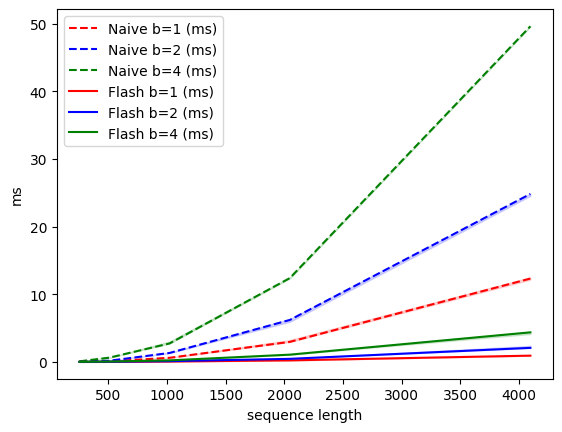

,seq_len,Naive b=1 (ms),Naive b=2 (ms),Naive b=4 (ms),Flash b=1 (ms),Flash b=2 (ms),Flash b=4 (ms)
0,256.0,0.042720,0.061024,0.098016,0.012000,0.016096,0.026112
1,512.0,0.095840,0.190016,0.646880,0.024288,0.040640,0.069312
2,1024.0,0.624352,1.340656,2.745856,0.071360,0.126656,0.243392
3,2048.0,2.976064,6.216448,12.408896,0.241344,0.468672,1.087168
4,4096.0,12.335840,24.840992,49.621616,0.939872,2.090496,4.382944


In [4]:
batch_sizes = [1, 2, 4]
seq_lengths = [256, 512, 1024, 2048, 4096]
providers = [("naive", b) for b in batch_sizes] + [("flash", b) for b in batch_sizes]
line_names = [f"Naive b={b}" for b in batch_sizes] + [f"Flash b={b}" for b in batch_sizes]
styles = [("red", "--"), ("blue", "--"), ("green", "--"), ("red", "-"), ("blue", "-"), ("green", "-")]


@perf_report(
    Benchmark(
        x_names=["seq_len"],
        x_vals=seq_lengths,
        x_log=False,
        line_arg="provider",
        line_vals=providers,
        line_names=line_names,
        styles=styles,
        ylabel="ms",
        xlabel="sequence length",
        plot_name="mini-llm-flash-attention-performance",
        args={"num_heads": 12, "qk_dim": 64, "v_dim": 64, "pad_ratio": 1 / 16},
    )
)
def bench_flash_attention(seq_len, provider, num_heads, qk_dim, v_dim, pad_ratio):
    impl, batch_size = provider
    q, k, v = make_qkv(batch_size, num_heads, seq_len, qk_dim, v_dim)
    mask = build_additive_mask(batch_size, seq_len, pad_ratio=pad_ratio)
    quantiles = [0.5, 0.2, 0.8]

    if impl == "naive":
        ms, min_ms, max_ms = do_bench(lambda: naive_attention(q, k, v, mask), quantiles=quantiles)
    elif impl == "flash":
        ms, min_ms, max_ms = do_bench(lambda: flash_attention_forward(q, k, v, mask), quantiles=quantiles)
    else:
        raise ValueError(f"unknown provider: {provider}")

    return ms, max_ms, min_ms


perf_df_raw = bench_flash_attention.run(show_plots=True, return_df=True)
perf_df_raw


3. 加速比可视化

In [5]:
perf_df = perf_df_raw.rename(columns=lambda x: x.replace(" (ms)", "").replace(" ()", "") if isinstance(x, str) else x)
speedup_rows = []
for batch_size in batch_sizes:
    naive_col = f"Naive b={batch_size}"
    flash_col = f"Flash b={batch_size}"
    for _, row in perf_df.iterrows():
        speedup_rows.append({
            "batch_size": batch_size,
            "seq_len": int(row["seq_len"]),
            "speedup": row[naive_col] / row[flash_col],
        })

speedup_df = pd.DataFrame(speedup_rows)
speedup_table = speedup_df.pivot(index="batch_size", columns="seq_len", values="speedup")

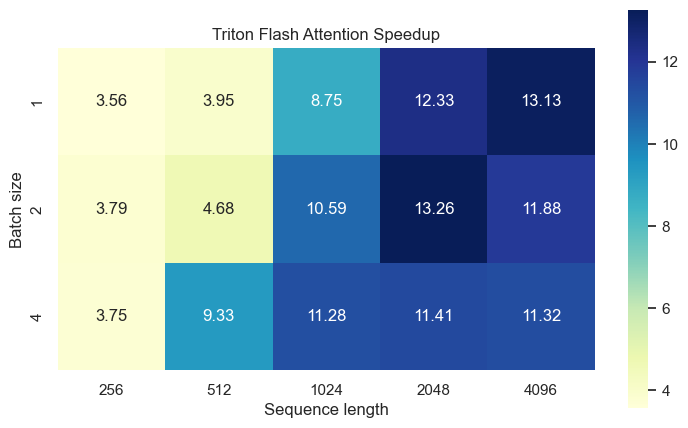

In [6]:
sns.set_theme(style="whitegrid")

n_rows, n_cols = speedup_table.shape
cell_size = 1.15
fig_w = n_cols * cell_size + 1.8
fig_h = n_rows * cell_size + 1.6

plt.figure(figsize=(fig_w, fig_h))
ax = sns.heatmap(
    speedup_table,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    square=True,
    cbar_kws={"shrink": 0.85},
)
ax.set_title("Triton Flash Attention Speedup")
ax.set_xlabel("Sequence length")
ax.set_ylabel("Batch size")
plt.tight_layout()
plt.show()
